In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import skimage.measure
from pathlib import Path

img = mpimg.imread('20230915_112407.jpg')

img = np.dot(img[...,:3], [0.2989, 0.5870, 0.1140])
img = np.swapaxes(img, 0, 1)
img = skimage.measure.block_reduce(img, (5,5), np.max)


In [8]:

img.shape

(807, 454)

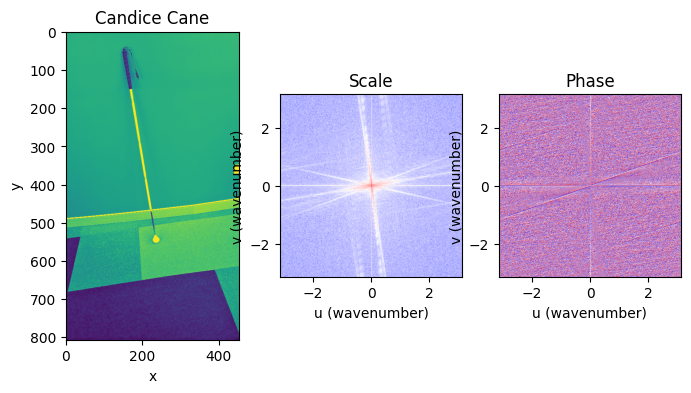

In [9]:

def plot_3panel(img, ft_img, out_path: str | None = None):

    fft_freqs_0 = np.fft.fftshift(np.fft.fftfreq(img.shape[0]) * 2*np.pi)
    fft_freqs_1 = np.fft.fftshift(np.fft.fftfreq(img.shape[1]) * 2.*np.pi)
    extent = (
        np.min(fft_freqs_1),
        np.max(fft_freqs_1),
        np.min(fft_freqs_0),
        np.max(fft_freqs_0),
    )
    
    fig, (ax, ax1, ax2) = plt.subplots(1,3, figsize=(8, 4))
    
    ax.imshow(
        img
    )
    ax.set(
        xlabel='x',
        ylabel='y',
        title='Candice Cane'
    )
    # ax.set_axis_off()
    
    ax1.imshow(
        np.log10(np.abs(ft_img)**2.),
        cmap='bwr',
        extent=extent
    )
    ax1.set(
        xlabel='u (wavenumber)',
        ylabel='v (wavenumber)',
        title='Scale'
    )
    # ax1.set_axis_off()
    
    ax2.imshow(
        np.angle(ft_img),
        cmap='bwr',
        extent=extent
    )
    ax2.set(
        xlabel='u (wavenumber)',
        ylabel='v (wavenumber)',
        title='Phase'
    )
    # ax2.set_axis_off()

  
    # fig.tight_layout()
    if out_path:
        fig.savefig(out_path)


ft_img = np.fft.fftshift(
    np.fft.fft2(img)
)

plot_3panel(img, ft_img)



radius=10
(807, 454)
[403 227]


/var/folders/3b/kbsb64bs78d1qzgmpfkgwq4800_fyl/T/ipykernel_42474/3084817152.py:25: RuntimeWarning: divide by zero encountered in log10
  np.log10(np.abs(ft_img)**2.),


radius=20
(807, 454)
[403 227]
radius=30
(807, 454)
[403 227]
radius=40
(807, 454)
[403 227]
radius=50
(807, 454)
[403 227]


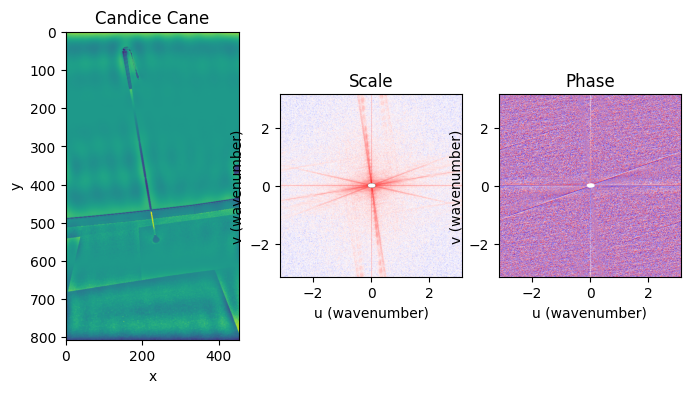

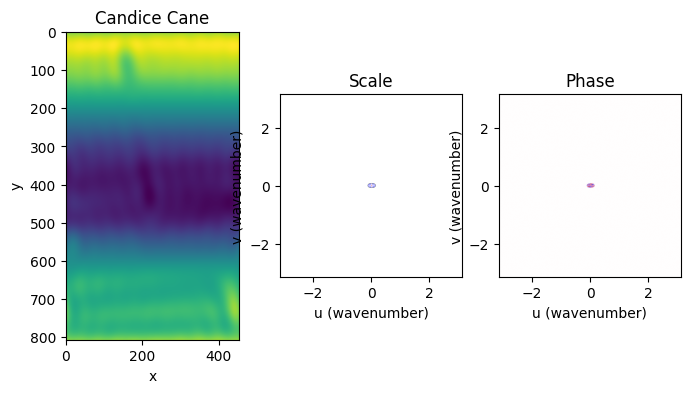

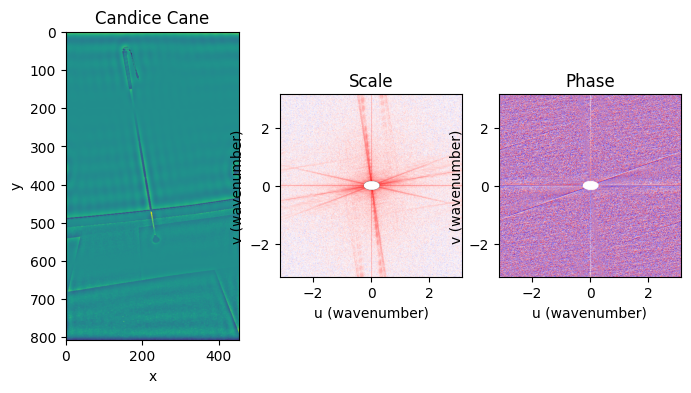

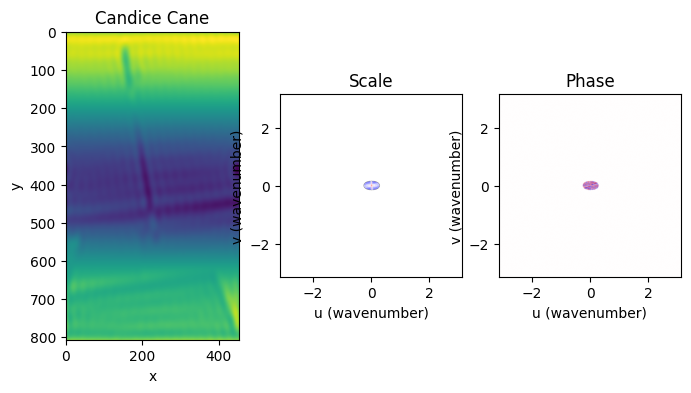

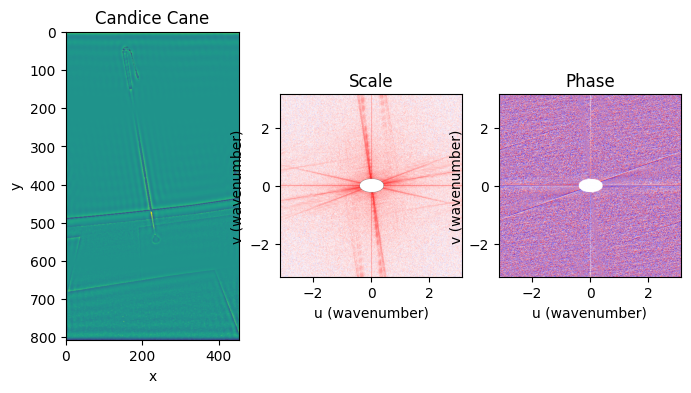

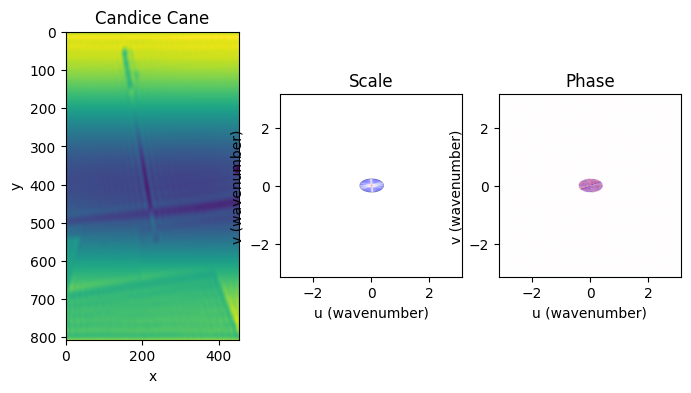

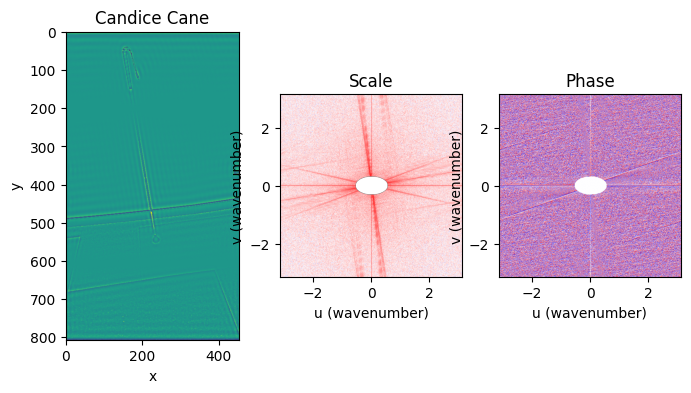

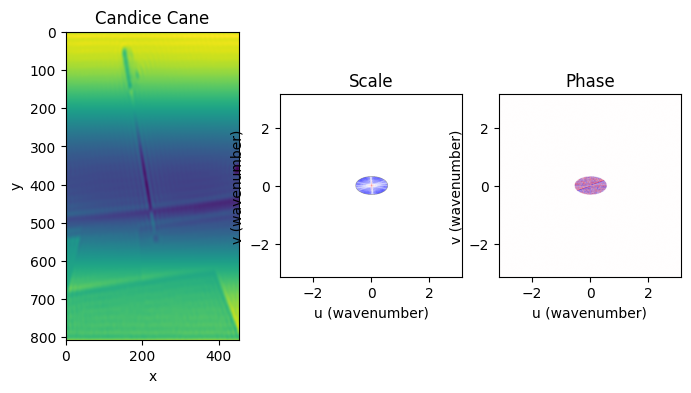

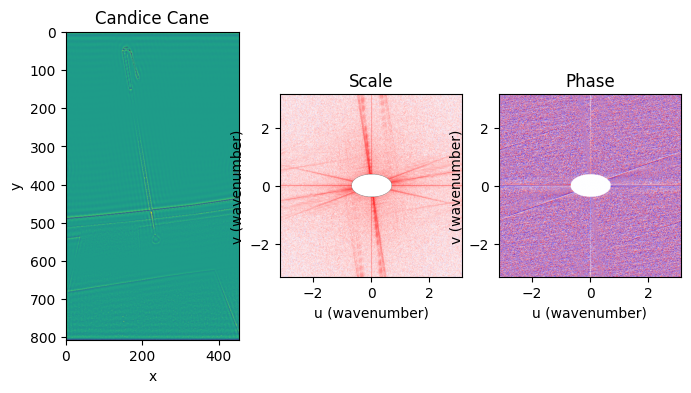

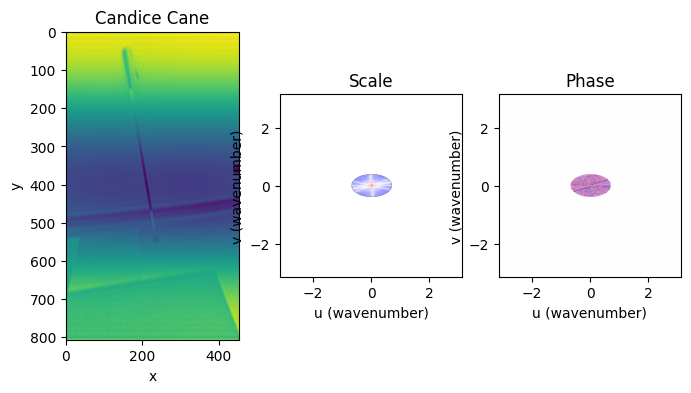

In [11]:

def make_cut_inner(img, radius, out_path: Path):
    y = np.arange(img.shape[0])
    x = np.arange(img.shape[1])

    xx, yy = np.meshgrid(x, y)

    print(xx.shape)

    center = np.array(img.shape) // 2
    print(center)

    mask = np.sqrt(
        (xx - center[1])**2 + (yy - center[0])**2
    ) < radius

    ft_img = np.fft.fftshift(
        np.fft.fft2(img)
    )

    ft_img[mask] = 0+0j

    mask_img = np.fft.ifft2(np.fft.fftshift(ft_img))

    
    og_type = out_path.suffix
    inner_path = out_path.with_suffix(f".inner-{radius}.{og_type}")
    outer_path = out_path.with_suffix(f".outer-{radius}.{og_type}")
    plot_3panel(mask_img.real, ft_img, out_path=inner_path)

    mask = np.sqrt(
        (xx - center[1])**2 + (yy - center[0])**2
    ) > radius

    ft_img = np.fft.fftshift(
        np.fft.fft2(img)
    )

    ft_img[mask] = 0+0j

    mask_img = np.fft.ifft2(np.fft.fftshift(ft_img))

    plot_3panel(mask_img.real, ft_img, out_path=outer_path)


for radius in (10, 20, 30, 40, 50):
    print(f"{radius=}")
    make_cut_inner(img=img, radius=radius, out_path=Path("example_plot.png"))



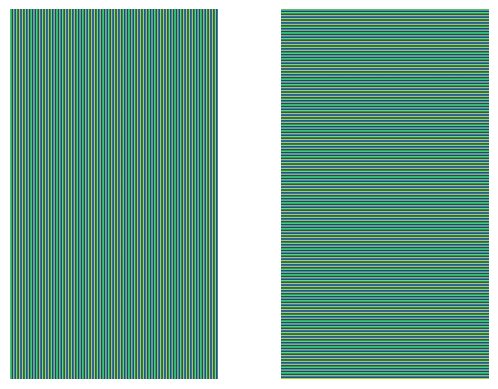

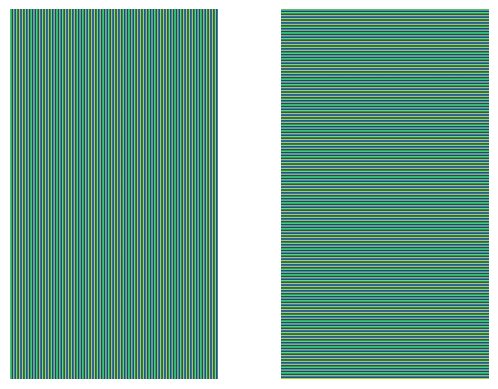

In [5]:
y = np.arange(img.shape[0])
x = np.arange(img.shape[1])

xx, yy = np.meshgrid(x, y)
rot = np.pi
cr = np.cos(rot)
sr = np.sin(rot)

rot_xx = y[:, None] + xx

# rot_xx = xx*cr - xx*sr
# rot_yy = yy*cr + yy*sr

fringe = np.zeros_like(img)

fringe_xx = np.sin(xx)
fringe_yy = np.sin(yy)

fig, (ax, ax1) = plt.subplots(1,2)

ax.imshow(fringe_xx)
ax1.imshow(fringe_yy)

ax.set_axis_off()
ax1.set_axis_off()


fig, (ax, ax1) = plt.subplots(1,2)

rot_xx = y[:, None] + xx

ax.imshow(fringe_xx)
ax1.imshow(fringe_yy)

ax.set_axis_off()
ax1.set_axis_off()



(162, 91)
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90]


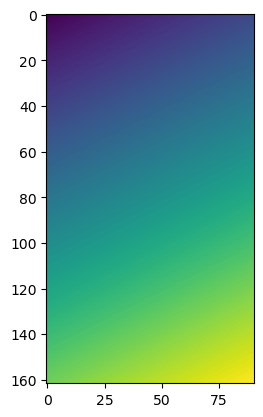

In [69]:
y = np.arange(img.shape[0])
x = np.arange(img.shape[1])

xx, yy = np.meshgrid(x, y)

fig, ax = plt.subplots(1,1)

print(xx.shape)
print(x)
xx = y[:, None] * 2 + xx

ax.imshow(xx)

In [54]:
y

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161])